In [1]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd  
from scipy.odr import Model, Data, RealData, ODR
from scipy import stats

In [2]:
data_d = '~/data/1_Single_Cell_PRS/2_cV2F/mvp_afr_0.9_0.01/20231221/406k_geno_v2_UKB_18PCs/fit_w_val'
base_d = '~/data/1_Single_Cell_PRS/2_cV2F/baselines/406k_geno_v2_UKB_18PCs/fit_w_val/baseline'

In [3]:
traits = ['INI20030780', 'INI10030760', 'INI10030870']

In [4]:
dfs = []
for t in traits:
    if t == 'INI20030780':
        liver_df = pd.read_csv(f'{data_d}/LIVER/{t}/exclude_APOE/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
        all_df = pd.read_csv(f'{data_d}/all/{t}/exclude_APOE/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
        base_df = pd.read_csv(f'~/data/1_Single_Cell_PRS/2_cV2F/baselines/406k_geno_v2_UKB_18PCs/fit_w_val/{t}/exclude_APOE/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    else:
        liver_df = pd.read_csv(f'{data_d}/LIVER/{t}/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
        all_df = pd.read_csv(f'{data_d}/all/{t}/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
        base_df = pd.read_csv(f'{base_d}/{t}/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    liver_df['Tissue'] = 'Liver'
    liver_df = liver_df[(liver_df['split'] == 'test') & (liver_df['population'] == 'Afr')]
    all_df['Tissue'] = 'Tissue-non-specific'
    all_df = all_df[(all_df['split'] == 'test') & (all_df['population'] == 'Afr')]
    base_df['Tissue'] = 'baseline'
    base_df = base_df[(base_df['split'] == 'test') & (base_df['population'] == 'Afr')]
    df = pd.concat([base_df, all_df, liver_df])
    dfs.append(df)

In [5]:
whole = pd.concat(dfs)
whole = whole[whole['model'] == 'PGS']

In [6]:
def linear_model(beta, x):
    return beta[0] * x 

In [7]:
prism = whole[whole['Tissue'] == 'Liver']
baseline = whole[whole['Tissue'] == 'baseline']

In [8]:
se_prism = prism['eval'] - prism['l_eval']
se_baseline = baseline['eval'] - baseline['l_eval']
se_diff = np.sqrt(np.square(se_prism) + np.square(se_baseline))
x = baseline['eval']
y = prism['eval'] - baseline['eval']
model = Model(linear_model)
data = RealData(x, y, sx=se_baseline, sy=se_diff)

odr = ODR(data, model, beta0=[1.0])  # Initial guess for parameters [a, b]
result = odr.run()
result.pprint()

Beta: [0.07161339]
Beta Std Error: [0.01337531]
Beta Covariance: [[0.12343457]]
Residual Variance: 0.0014493416417779969
Inverse Condition #: 1.0
Reason(s) for Halting:
  Sum of squares convergence


In [9]:
df = len(x) - 1  # equivalently, degree of freedom (n_sample - n_param)
beta_0 = 0  # test if slope is significantly different from zero
t_stat = (result.beta[0] - beta_0) / (result.sd_beta[0])  # t statistic for the slope parameter
p_val = stats.t.sf(np.abs(t_stat), df)
print('Recovered equation: y={:3.3f}x, t={:3.3f}, p={:f}'.format(result.beta[0], t_stat, p_val))

Recovered equation: y=0.072x, t=5.354, p=0.016579


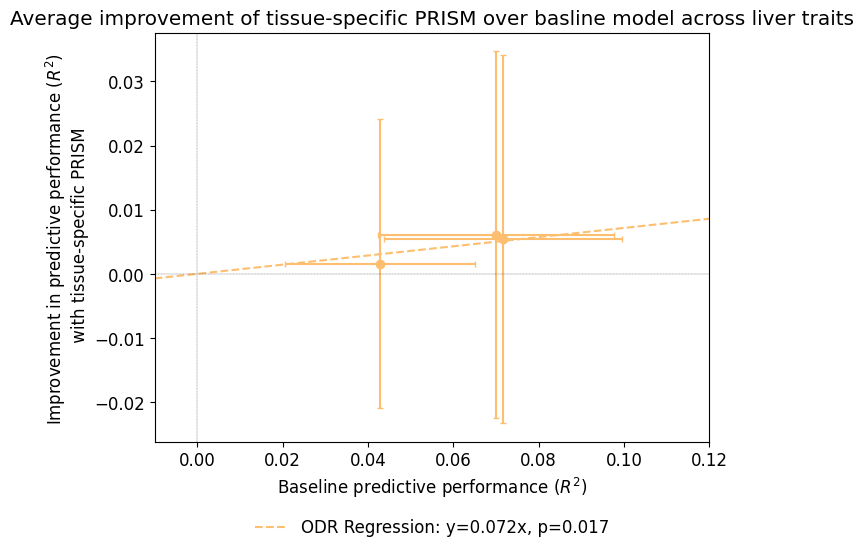

In [10]:
palette = sns.color_palette(palette='Paired')

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})


fig, ax = plt.subplots()
fig.tight_layout()
#fig.subplots_adjust(top=1.5, bottom=0.2) 
er1 = ax.errorbar(x=x, y=y, yerr=se_prism, xerr=se_baseline, fmt='o', capsize=2, color = palette[6])

ax.set_xlim(-0.01, 0.12) # Adjust these two numbers if you want it wider or narrower!
trait = ['LDL-C', 'HDL-C', 'Triglycerides']




#for i, txt in enumerate(trait):
    #ax.annotate(txt, (x.tolist()[i], y.tolist()[i]), 
                #textcoords="offset points", 
                #xytext=(7, 5), 
                #ha='left', 
                #va='bottom',
                #fontsize=9)

# 4. Now capture those explicit limits so the line spans wall-to-wall
x_limits = ax.get_xlim()
x_fit = np.linspace(x_limits[0], x_limits[1], 100)
slope = result.beta[0]
y_fit = slope * x_fit
ax.plot(x_fit, y_fit, label='ODR Regression: y=0.072x, p=0.017', linestyle='--', color=palette[6])

ax.axhline(y=0, linestyle='--', color='black', linewidth=0.2)
ax.axvline(x=0, linestyle='--', color='black', linewidth=0.2)
ax.set_xlabel(r'Baseline predictive performance ($R^{2}$)');
ax.set_ylabel('Improvement in predictive performance ($R^{2}$) \n with tissue-specific PRISM');

#for i, txt in enumerate(trait):
    #ax.annotate(txt, (afr['eval_eur'][i], afr['eval_afr'][i]))
ax.set_title('Average improvement of tissue-specific PRISM over basline model across liver traits');

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)
#ax.figure.savefig('improve_combined_agnostic.pdf', bbox_inches='tight')